In [1]:
import pandas as pd
import numpy as np
from utils import build_feature_matrix
import gc

In [2]:
# Read metadata and preprocess the image paths
metadata = pd.read_json("metadata.jsonl", lines=True)
metadata["image_path"] = metadata["image_path"].str.replace(
    "/content/drive/MyDrive/fruitveg_data/", "",
    regex=False
)

### Extract Features from Images

In [5]:
# Build feature matrix
zip_path1 = "images.zip"
zip_path2 = "images2.zip"
zip_path3 = "images3.zip"
X1, paths1 = build_feature_matrix(zip_path1)
X2, paths2 = build_feature_matrix(zip_path2)
X3, paths3 = build_feature_matrix(zip_path3)
paths2 = np.char.replace(paths2, "images", "images2") # Adjust paths for second dataset
paths3 = np.char.replace(paths3, "images", "images3") # Adjust paths for third dataset

In [6]:
# Stack feature matrices
X = np.concatenate(([X1, X2, X3]), axis=0)
paths = np.concatenate(([paths1, paths2, paths3]), axis=0)

# Free up memory 
del X1, X2, X3
gc.collect()

0

In [7]:
# Create DataFrame with features and paths
n_samples, n_features = X.shape
feature_cols = [f"f{i}" for i in range(n_features)]
df_feats = pd.DataFrame(X, columns=feature_cols)
df_feats["path"] = paths

# Free up memory 
del X
gc.collect()

0

In [8]:
# Merge features with metadata
df = df_feats.merge(metadata, left_on="path", right_on="image_path", how="inner")

In [9]:
# Eliminate Outliers (It was previously labeled)
df = df[df["is_outlier"]==False]

In [4]:
# Create seperate dataframes for training different models using only images, only categorical and numerical attributes, and fused features.
df_extracted_feats = df.drop(['image_path', 'path_x', 'color', 'season', 'origin',
       'weight_g', 'ripeness', 'defects_flag', 'prompt', 'seed', 'height',
       'width', 'steps', 'guidance', 'model', 'path_y', 'is_outlier'], axis=1)

df_num_cat_feats = df[['class', 'color', 'season', 'origin',
       'weight_g', 'ripeness', 'height', 'width']]

df_fused_feats = df.drop(['image_path', 'defects_flag', 'path_x','prompt', 'seed', 'steps', 'guidance', 'model', 'path_y', 'is_outlier'], axis=1)

### Intra & Inter Class Similarity Analysis Using Cosine Similarity

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

X = df_extracted_feats.drop(["class"], axis=1).values 
y = df_extracted_feats["class"].values

classes = np.unique(y)
similarity_matrix = pd.DataFrame(index=classes, columns=classes, dtype=float)

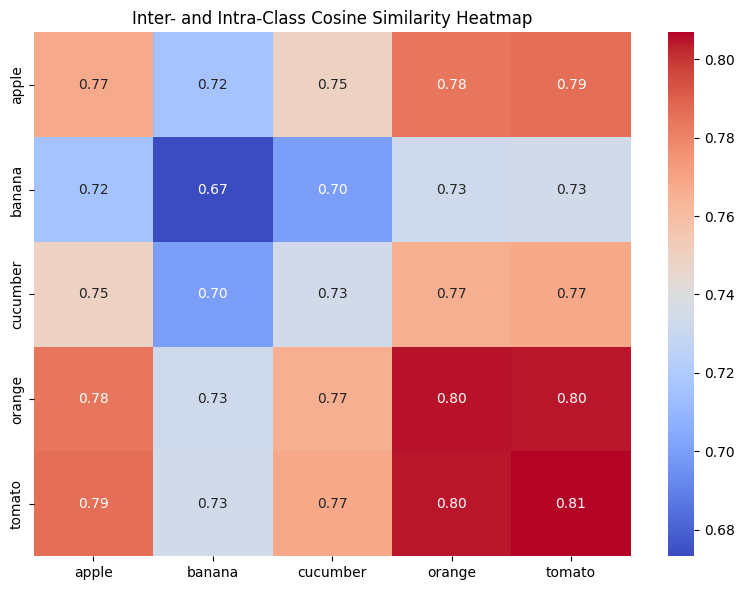

In [12]:
for c1 in classes:
    for c2 in classes:
        X1 = X[y == c1]
        X2 = X[y == c2]
        sims = cosine_similarity(X1, X2)
        similarity_matrix.loc[c1, c2] = sims.mean()

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Inter- and Intra-Class Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()

- For banana, intra-class similarity is lower than the inter-class similarities which is a bit weird and unexpected. Overall, inter- and intra- class similarities are not much different could mean that extracted features are non-discriminative.

### Outlier Analysis Using z-scores

In [5]:
feature_cols = [c for c in df_extracted_feats.columns if c.startswith("f")]

# Group by class and z-score *within each class*
def zscore_group(g):
    return (g - g.mean()) / g.std()

df_z = df_extracted_feats.groupby("class")[feature_cols].transform(zscore_group)

In [14]:
threshold = 2
df_extracted_feats[df_z.abs().mean(axis=1) > threshold].groupby("class")["class"].sum()

Series([], Name: class, dtype: object)

- None outlier is detected using the mean of absolute z-scores across features since the dataset is iteratively generated by eliminating the outliers.

### Model Training & Evaluation

In [5]:
from preprocess_train_helpers import train_eval_logreg, build_X_num_only, build_X_cat_num
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#### 1) Training model on df_extracted_feats (Only using the extracted features from images)

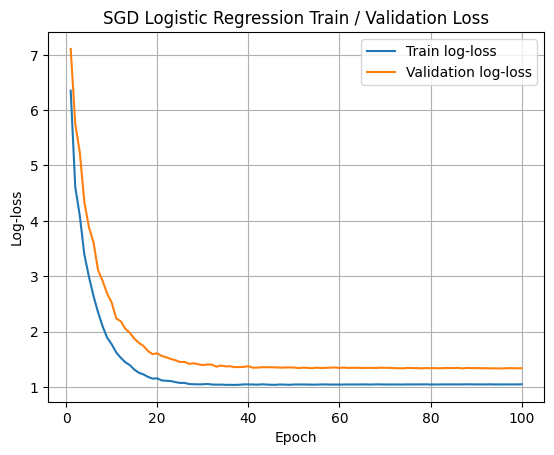

Accuracy:  0.4564
Macro F1:  0.4512
ROC AUC:   0.7631
Precision: 0.4506
Recall:    0.4564


In [6]:
X_ext, y_ext = build_X_num_only(df_extracted_feats, target_col='class')
le = LabelEncoder()
y_ext = le.fit_transform(y_ext)

X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_ext, y_ext, test_size=0.2, random_state=42, stratify=y_ext
)

clf_ext, scaler_ext = train_eval_logreg(X_ext_train, X_ext_test, y_ext_train, y_ext_test)


#### 2) Model on df_num_cat_feats (Using the all features Without extracted features from images)

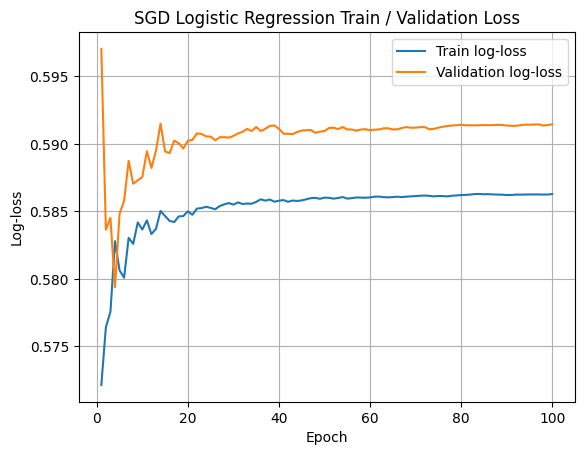

Accuracy:  0.7466
Macro F1:  0.7130
ROC AUC:   0.9405
Precision: 0.7592
Recall:    0.7471


In [7]:
numerical_cols = ['weight_g', 'height', 'width']
categorical_cols = ['color', 'season', 'origin', 'ripeness']

X_cat_num, y = build_X_cat_num(df_num_cat_feats, categorical_cols, numerical_cols, target_col='class')
le = LabelEncoder()
y_cat_num = le.fit_transform(y)

X_cat_num_train, X_cat_num_test, y_cat_num_train, y_cat_num_test = train_test_split(
    X_cat_num, y_cat_num, test_size=0.2, random_state=42, stratify=y_cat_num
)

clf_cat_num, scaler_cat_num = train_eval_logreg(X_cat_num_train, X_cat_num_test, y_cat_num_train, y_cat_num_test)

#### 3) Model on df_fused_feats (Using all the features)

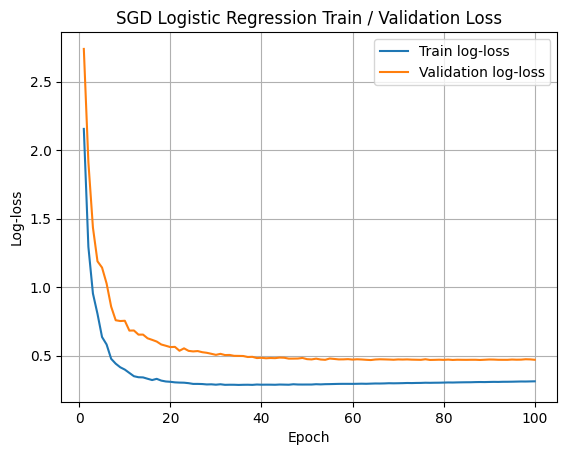

Accuracy:  0.8054
Macro F1:  0.8070
ROC AUC:   0.9614
Precision: 0.8102
Recall:    0.8056


In [8]:
categorical_cols = ['color', 'season', 'origin', 'ripeness']
numerical_cols = [i for i in df_fused_feats.columns if i not in (categorical_cols + ['class'])]

X_cat_num, y = build_X_cat_num(df_fused_feats, categorical_cols, numerical_cols, target_col='class')
le = LabelEncoder()
y_cat_num = le.fit_transform(y)

X_cat_num_train, X_cat_num_test, y_cat_num_train, y_cat_num_test = train_test_split(
    X_cat_num, y_cat_num, test_size=0.2, random_state=42, stratify=y_cat_num
)

clf_cat_num, scaler_cat_num = train_eval_logreg(X_cat_num_train, X_cat_num_test, y_cat_num_train, y_cat_num_test)